In [1]:
import os
import sys
import warnings

sys.path.append(os.path.abspath("../scripts"))
warnings.filterwarnings("ignore")


import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


from data_preprocessing import preprocess_for_nn
from boosting_models import run_lr_tuning, run_catboost_tuning, run_lgbm_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate
from metric_utils import bootstrap_metrics

## Датасет [Diabets](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

In [2]:
import kagglehub

path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database") + "/diabetes.csv"

df = pd.read_csv(path)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]
le = LabelEncoder()
y = le.fit_transform(y)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y, shuffle=True)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size=0.5, random_state=0, stratify=y_test, shuffle=True)

In [5]:
categorical_features = []
numerical_features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
column_transformer = ColumnTransformer([
        ("ohe", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("scaling", StandardScaler(), numerical_features)
])

In [6]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
metrics_lr = bootstrap_metrics(y_test, y_pred_lr, y_prob_lr)

[I 2025-04-21 17:39:24,440] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-21 17:39:24,449] Trial 0 finished with value: 0.8025925925925926 and parameters: {'penalty': 'l1', 'C': 0.01}. Best is trial 0 with value: 0.8025925925925926.
[I 2025-04-21 17:39:24,456] Trial 1 finished with value: 0.9059259259259258 and parameters: {'penalty': 'l2', 'C': 100}. Best is trial 1 with value: 0.9059259259259258.
[I 2025-04-21 17:39:24,463] Trial 2 finished with value: 0.8711111111111111 and parameters: {'penalty': 'l2', 'C': 0.0001}. Best is trial 1 with value: 0.9059259259259258.
[I 2025-04-21 17:39:24,468] Trial 3 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.001}. Best is trial 1 with value: 0.9059259259259258.
[I 2025-04-21 17:39:24,475] Trial 4 finished with value: 0.9059259259259258 and parameters: {'penalty': 'l2', 'C': 100}. Best is trial 1 with value: 0.9059259259259258.
[I 2025-04-21 17:39:24,482] Trial 5 finished with value: 0.905

In [7]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_cb  = model_cb.predict(X_test)
y_prob_cb  = model_cb.predict_proba(X_test)[:, 1]
metrics_cb = bootstrap_metrics(y_test, y_pred_cb, y_prob_cb)

[I 2025-04-21 17:39:27,638] A new study created in memory with name: catboost_optimization
[I 2025-04-21 17:39:30,575] Trial 0 finished with value: 0.9037037037037038 and parameters: {'depth': 10, 'learning_rate': 0.01, 'l2_leaf_reg': 0.1}. Best is trial 0 with value: 0.9037037037037038.
[I 2025-04-21 17:39:33,127] Trial 1 finished with value: 0.8696296296296295 and parameters: {'depth': 10, 'learning_rate': 0.3, 'l2_leaf_reg': 0.1}. Best is trial 0 with value: 0.9037037037037038.
[I 2025-04-21 17:39:33,453] Trial 2 finished with value: 0.8948148148148147 and parameters: {'depth': 2, 'learning_rate': 0.1, 'l2_leaf_reg': 3.0}. Best is trial 0 with value: 0.9037037037037038.
[I 2025-04-21 17:39:33,776] Trial 3 finished with value: 0.8911111111111112 and parameters: {'depth': 2, 'learning_rate': 0.3, 'l2_leaf_reg': 6.0}. Best is trial 0 with value: 0.9037037037037038.
[I 2025-04-21 17:39:34,832] Trial 4 finished with value: 0.8948148148148147 and parameters: {'depth': 8, 'learning_rate': 

In [8]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lgbm = model_lgbm.predict(X_test)
y_prob_lgbm = model_lgbm.predict_proba(X_test)[:, 1]
metrics_lgbm = bootstrap_metrics(y_test, y_pred_lgbm, y_prob_lgbm)

[I 2025-04-21 17:39:51,284] A new study created in memory with name: lightgbm_optimization
[I 2025-04-21 17:39:51,980] Trial 0 finished with value: 0.8681481481481481 and parameters: {'num_leaves': 16, 'reg_alpha': 1e-06, 'reg_lambda': 1e-05, 'learning_rate': 0.03}. Best is trial 0 with value: 0.8681481481481481.
[I 2025-04-21 17:39:52,185] Trial 1 finished with value: 0.8725925925925926 and parameters: {'num_leaves': 4, 'reg_alpha': 0.01, 'reg_lambda': 1e-05, 'learning_rate': 0.3}. Best is trial 1 with value: 0.8725925925925926.
[I 2025-04-21 17:39:53,125] Trial 2 finished with value: 0.8770370370370371 and parameters: {'num_leaves': 512, 'reg_alpha': 1e-05, 'reg_lambda': 1e-08, 'learning_rate': 0.1}. Best is trial 2 with value: 0.8770370370370371.
[I 2025-04-21 17:39:54,847] Trial 3 finished with value: 0.8703703703703703 and parameters: {'num_leaves': 4096, 'reg_alpha': 1e-08, 'reg_lambda': 0.001, 'learning_rate': 0.01}. Best is trial 2 with value: 0.8770370370370371.
[I 2025-04-21 

In [9]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [10]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 128
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [11]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


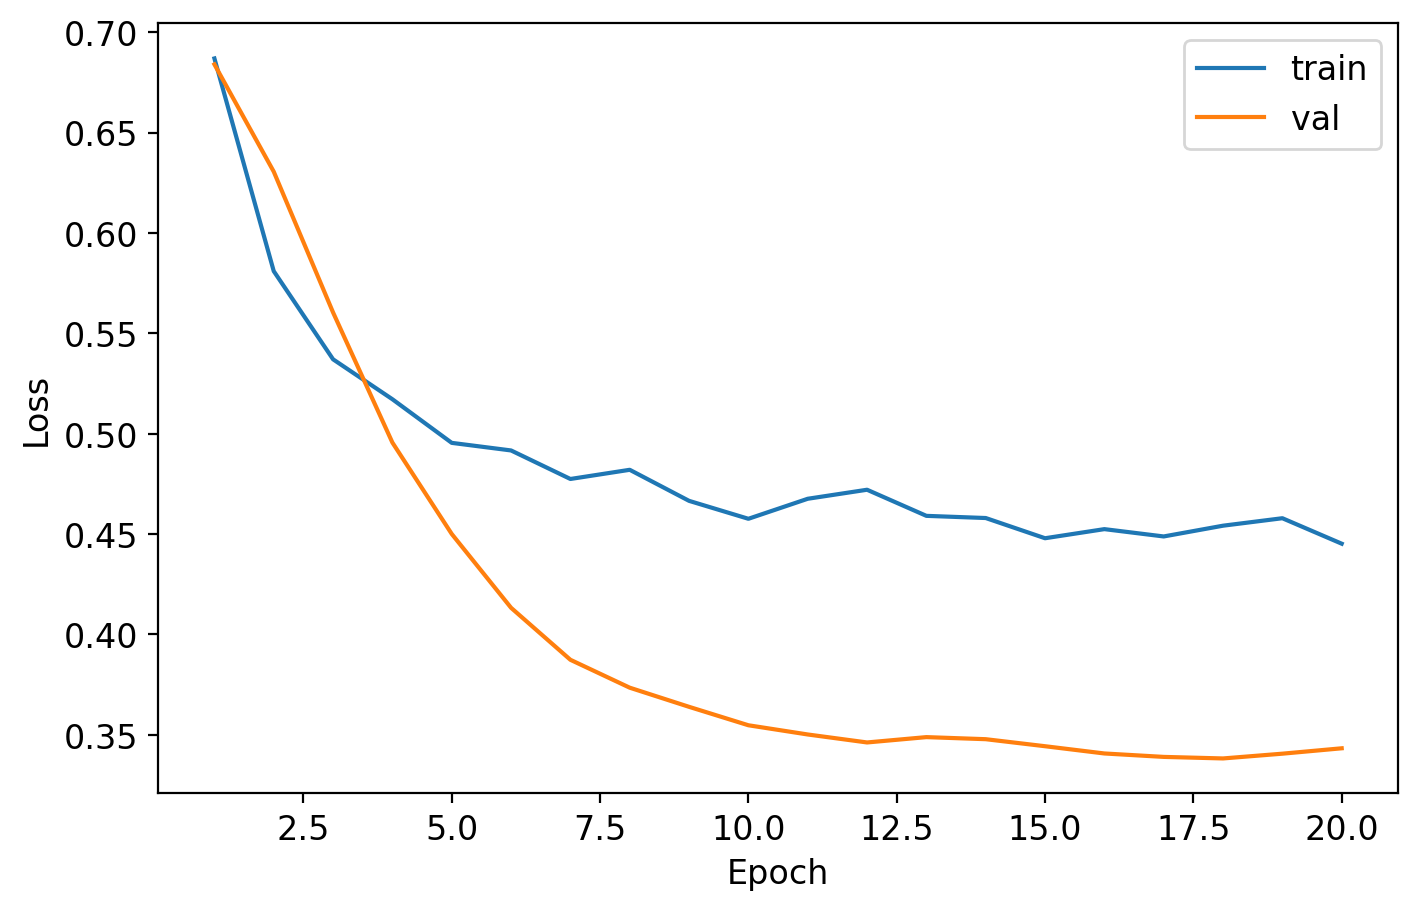

Epoch 20: train loss = 0.4452; valid loss = 0.3433


In [13]:
net = TABMLP(len(numerical_features), emb_dims).to(device)
optimizer = optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 20, train_loader, val_loader, criterion, device)

In [14]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device)
metrics_nn = bootstrap_metrics(y_true, y_pred, y_prob)

In [15]:
res = pd.DataFrame([{"model": "Logistic regression"} | metrics_lr, {"model": "CatBoost"} | metrics_cb, {"model": "LightGBM"} | metrics_lgbm, {"model": "TABMLP"} | metrics_nn])
res

,model,ROC-AUC,F1,Accuracy,Precision,Recall
0,Logistic regression,0.8665±0.0426,0.6461±0.0798,0.7786±0.0468,0.7225±0.0953,0.5917±0.0937
1,CatBoost,0.8316±0.0526,0.6602±0.0825,0.7922±0.0473,0.7592±0.0978,0.5912±0.0958
2,LightGBM,0.8105±0.0551,0.5899±0.0848,0.7531±0.0483,0.6948±0.1039,0.5204±0.0956
3,TABMLP,0.8591±0.0446,0.6757±0.0774,0.7931±0.0461,0.7377±0.0918,0.6307±0.0936
